# External Read Access to Unity Catalog Managed Iceberg Tables

## Overview

This notebook demonstrates how to enable **external open-source Apache Spark clients** to query Unity Catalog–managed Iceberg tables in Databricks. This showcases the power of open standards and vendor-neutral data access with read-only SELECT permissions.

## What You'll Learn

- 🔧 **External Spark Configuration**: Set up OSS Spark with Iceberg and Unity Catalog integration
- 🔐 **Authentication & Authorization**: Securely connect to UC-managed tables using REST API
- 📊 **Data Querying**: Read and analyze data from external clients using SELECT access
- 🐼 **Zero-Copy Integration**: Convert Spark DataFrames to Pandas for advanced analytics
- 📈 **Data Visualization**: Create compelling visualizations with matplotlib
- ⚾ **Real-World Use Case**: Work with comprehensive MLB pitch-by-pitch game data (2023-2025)

## Key Benefits

- **Vendor Independence**: No vendor lock-in - use any Spark-compatible platform
- **Centralized Governance**: Unity Catalog maintains metadata, permissions, and audit trails
- **Open Standards**: Built on Apache Iceberg for maximum interoperability
- **Secure Access**: Authentication tokens ensure controlled external access
- **Cost Efficiency**: External compute can access managed storage without data duplication

## Prerequisites

- Databricks workspace with Unity Catalog enabled
- Access token with SELECT permissions on the target table
- Python environment with PySpark, Pandas, and Matplotlib capabilities
- Unity Catalog managed Iceberg table (`game_report_iceberg` with MLB pitch data)


In [1]:
# Install required dependencies for PyIceberg client
# Uncomment the lines below if running in a fresh environment
# %pip install pyiceberg[s3fs,pyarrow,pandas] duckdb matplotlib seaborn

# PyIceberg is the official Python library for Apache Iceberg
# It provides native REST catalog support for Unity Catalog


In [2]:
from config import *


## 1. PyIceberg Catalog Configuration

Setting up PyIceberg to connect to Unity Catalog managed Iceberg tables requires:

1. **PyIceberg Library**: Native Python implementation of Apache Iceberg
2. **REST Catalog**: Direct connection to Unity Catalog's Iceberg REST API
3. **Authentication**: Bearer token for secure access
4. **DuckDB Integration**: For SQL querying capabilities


In [3]:
from pyiceberg.catalog import load_catalog
import duckdb
import os

# Set AWS region as environment variable (required for credential vending)
os.environ["AWS_REGION"] = AWS_REGION
os.environ["AWS_DEFAULT_REGION"] = AWS_REGION

# Configure PyIceberg catalog for Unity Catalog
catalog = load_catalog(
    "unity_catalog",
    **{
        "type": "rest",
        "uri": f"https://{WORKSPACE_URI}/api/2.1/unity-catalog/iceberg-rest",
        "token": ACCESS_TOKEN,
        "warehouse": UC_CATALOG_NAME,
    }
)

print("✅ PyIceberg catalog connected successfully!")
print(f"Catalog name: {UC_CATALOG_NAME}")
print(f"Workspace: {WORKSPACE_URI}")
print(f"AWS Region: {AWS_REGION}")
print(f"\n🔧 Using PyIceberg with Unity Catalog REST API")
print(f"   PyIceberg provides native Iceberg table access without Spark")


✅ PyIceberg catalog connected successfully!
Catalog name: mlb_demos
Workspace: fe-sandbox-stable-classic-jy18p5.cloud.databricks.com
AWS Region: us-east-1

🔧 Using PyIceberg with Unity Catalog REST API
   PyIceberg provides native Iceberg table access without Spark


## 2. Data Exploration - Understanding the MLB Game Report Dataset

Let's explore our Unity Catalog managed Iceberg table containing comprehensive MLB pitch-by-pitch game data. This table includes:
- **Game metadata**: Teams, venue, weather conditions, dates (2023-2025)
- **Pitch details**: Type, speed, spin rate, break, location
- **Hit data**: Launch speed, angle, distance, trajectory
- **Player info**: Batter and pitcher names, handedness
- **ML predictions**: Strike probability from our trained model


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Set catalog and database for Iceberg
iceberg_db = "mlb_gumbo_gold"
table_name = "game_report_iceberg"
full_table_name = f"{iceberg_db}.{table_name}"

# Configure which league level to analyze
# Options: "Major League Baseball" or "Triple-A"
LEAGUE_LEVEL = "Major League Baseball"  # Change this to "Triple-A" to analyze minor league data

print(f"📊 Connecting to table: {full_table_name}")
print(f"🏟️  Analyzing: {LEAGUE_LEVEL}")

# Load the Iceberg table
try:
    table = catalog.load_table(full_table_name)
    print(f"✅ Successfully loaded table: {full_table_name}")
    print(f"   Table format version: {table.metadata.format_version}")
    print(f"   Number of snapshots: {len(list(table.metadata.snapshots))}")
except Exception as e:
    print(f"❌ Error loading table: {e}")
    print(f"   Make sure the table exists and you have SELECT permissions")


📊 Connecting to table: mlb_gumbo_gold.game_report_iceberg
🏟️  Analyzing: Major League Baseball
✅ Successfully loaded table: mlb_gumbo_gold.game_report_iceberg
   Table format version: 2
   Number of snapshots: 1


In [5]:
# Read table data into a PyArrow table, then convert to pandas
print("📥 Reading table data (this may take a moment)...")

# Use PyIceberg to scan the table and convert to pandas
df = table.scan().to_pandas()

print(f"✅ Data loaded successfully!")
print(f"⚾ Total pitches in dataset: {len(df):,}")
print(f"📊 Columns: {len(df.columns)}")
print(f"💾 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Get season breakdown
season_summary = df.groupby(['season']).agg({
    'pitch_index': 'count',
    'game_pk': 'nunique'
}).rename(columns={'pitch_index': 'pitch_count', 'game_pk': 'game_count'})

print("\n📅 Data by Season:")
print(season_summary)


📥 Reading table data (this may take a moment)...
✅ Data loaded successfully!
⚾ Total pitches in dataset: 1,446,477
📊 Columns: 41
💾 Memory usage: 1452.45 MB

📅 Data by Season:
        pitch_count  game_count
season                         
2024         722297        2472
2025         724180        2477


## (Optional) Using DuckDB for SQL Queries

PyIceberg works great with pandas, but if you prefer SQL, you can use DuckDB to query the pandas DataFrame:


In [6]:
# Example: Query the pandas DataFrame using SQL with DuckDB
# DuckDB provides a SQL interface over in-memory data

conn = duckdb.connect()
conn.register('game_data', df)

# Run a SQL query
result = conn.execute("""
    SELECT 
        season,
        COUNT(*) as total_pitches,
        ROUND(AVG(pitch_start_speed), 2) as avg_velocity
    FROM game_data
    GROUP BY season
    ORDER BY season
""").fetchdf()

print("📊 Example DuckDB SQL Query Result:")
print(result)

conn.close()

print("\n💡 You can use either pandas operations or SQL queries with DuckDB!")


📊 Example DuckDB SQL Query Result:
   season  total_pitches  avg_velocity
0    2024         722297         89.17
1    2025         724180         89.40

💡 You can use either pandas operations or SQL queries with DuckDB!


## 3. Pitcher Performance Analysis

Let's analyze pitcher performance using our ML model's strike probability predictions. We'll identify the most effective pitchers at getting called strikes.


In [7]:
# Top pitchers by average strike probability (min 500 pitches)
print(f"🏆 Top 20 {LEAGUE_LEVEL} Pitchers by Strike Probability (Min 500 pitches):")

# Filter and aggregate using pandas
pitcher_pd = df[df['called_strike_probability'].notna()].groupby(['pitcher_full_name', 'pitcher_hand_description']).agg({
    'pitch_index': 'count',
    'called_strike_probability': 'mean',
    'pitch_start_speed': 'mean',
    'pitch_spin_rate': 'mean'
}).rename(columns={
    'pitch_index': 'total_pitches',
    'called_strike_probability': 'avg_strike_prob',
    'pitch_start_speed': 'avg_velocity',
    'pitch_spin_rate': 'avg_spin_rate'
}).reset_index()

# Filter for min 500 pitches
pitcher_pd = pitcher_pd[pitcher_pd['total_pitches'] >= 500]

# Round values
pitcher_pd['avg_strike_prob'] = pitcher_pd['avg_strike_prob'].round(3)
pitcher_pd['avg_velocity'] = pitcher_pd['avg_velocity'].round(1)
pitcher_pd['avg_spin_rate'] = pitcher_pd['avg_spin_rate'].round(0).astype(int)

# Sort and limit to top 20
pitcher_pd = pitcher_pd.sort_values('avg_strike_prob', ascending=False).head(20)

print(pitcher_pd.to_string(index=False))


🏆 Top 20 Major League Baseball Pitchers by Strike Probability (Min 500 pitches):
pitcher_full_name pitcher_hand_description  total_pitches  avg_strike_prob  avg_velocity  avg_spin_rate
     Tyler Rogers                    Right           1972            0.612          80.1           2092
      Kyle Muller                     Left            722            0.567          88.5           2204
      Max Kranick                    Right            534            0.566          90.3           2256
 Brandon Woodruff                    Right            964            0.564          90.1           2263
    Justin Steele                     Left           2359            0.563          88.5           2482
    Kenley Jansen                    Right           1665            0.561          91.7           2576
    Robert Gasser                     Left            561            0.558          88.1           2250
    Miles Mikolas                    Right           5188            0.557          87.

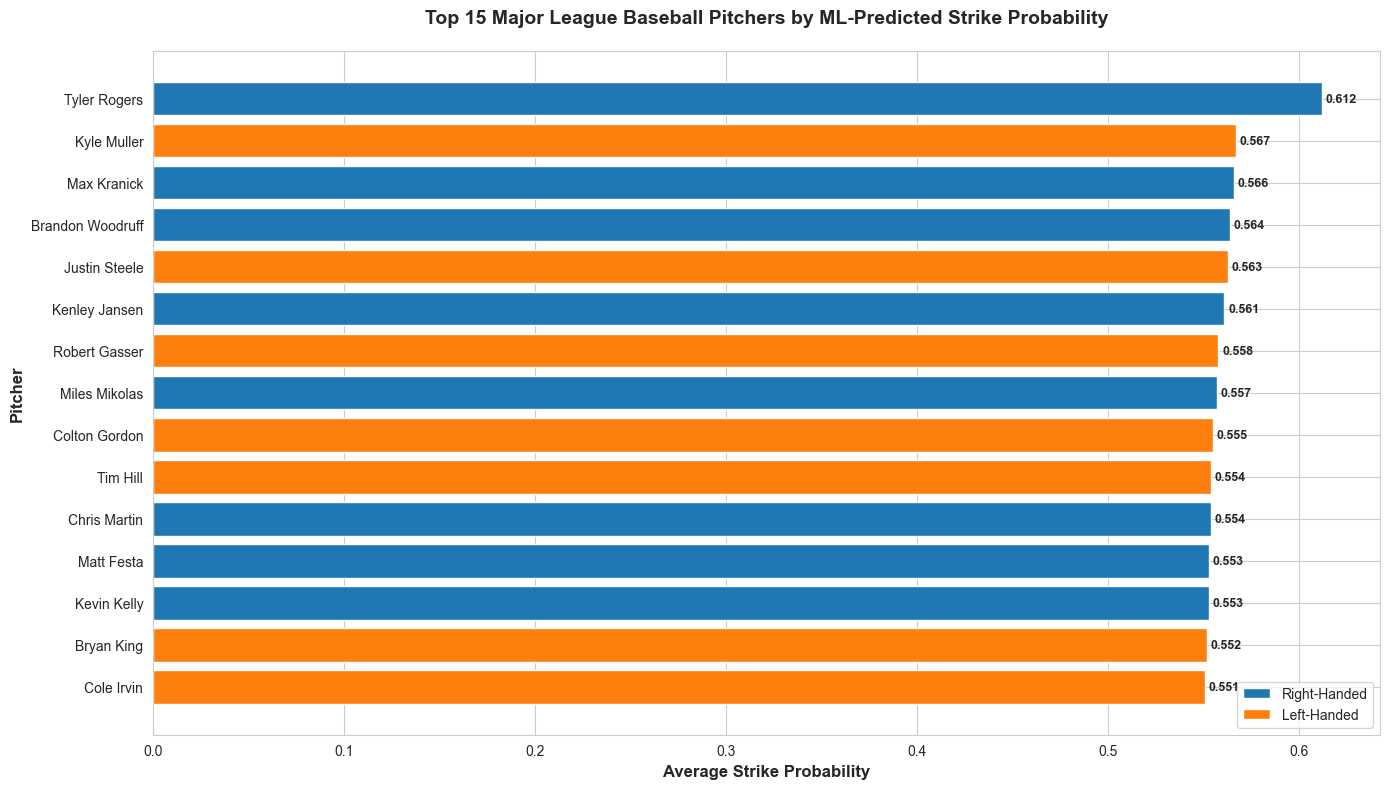


📊 Chart displays the top 15 Major League Baseball pitchers most likely to get called strikes based on ML predictions


In [8]:
# Visualize top pitchers
fig, ax = plt.subplots(figsize=(14, 8))

# Take top 15 for better readability
top_15 = pitcher_pd.head(15)
colors = ['#1f77b4' if hand == 'Right' else '#ff7f0e' for hand in top_15['pitcher_hand_description']]

bars = ax.barh(top_15['pitcher_full_name'], top_15['avg_strike_prob'], color=colors)
ax.set_xlabel('Average Strike Probability', fontsize=12, fontweight='bold')
ax.set_ylabel('Pitcher', fontsize=12, fontweight='bold')
ax.set_title(f'Top 15 {LEAGUE_LEVEL} Pitchers by ML-Predicted Strike Probability', 
             fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

# Add value labels on bars
for i, (bar, prob) in enumerate(zip(bars, top_15['avg_strike_prob'])):
    ax.text(prob + 0.002, bar.get_y() + bar.get_height()/2, f'{prob:.3f}', 
            va='center', fontsize=9, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Right-Handed'),
                   Patch(facecolor='#ff7f0e', label='Left-Handed')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 Chart displays the top 15 {LEAGUE_LEVEL} pitchers most likely to get called strikes based on ML predictions")


## 4. Pitch Type Effectiveness Analysis

Analyzing which pitch types are most effective across different situations.


In [9]:
# Analyze pitch type effectiveness
print(f"⚾ {LEAGUE_LEVEL} Pitch Type Effectiveness (Min 1000 pitches):")

# Calculate strike percentage
df_strikes = df.copy()
df_strikes['is_strike'] = df_strikes['call_description'].isin(['Called Strike', 'Swinging Strike']).astype(int)

# Group by pitch type
pitch_type_pd = df_strikes[df_strikes['pitch_type_description'].notna()].groupby('pitch_type_description').agg({
    'pitch_index': 'count',
    'pitch_start_speed': 'mean',
    'pitch_spin_rate': 'mean',
    'called_strike_probability': 'mean',
    'is_strike': lambda x: (x.sum() / len(x) * 100)
}).rename(columns={
    'pitch_index': 'pitch_count',
    'pitch_start_speed': 'avg_velocity',
    'pitch_spin_rate': 'avg_spin_rate',
    'called_strike_probability': 'avg_strike_prob',
    'is_strike': 'strike_pct'
}).reset_index()

# Filter for min 1000 pitches
pitch_type_pd = pitch_type_pd[pitch_type_pd['pitch_count'] >= 1000]

# Round values
pitch_type_pd['avg_velocity'] = pitch_type_pd['avg_velocity'].round(1)
pitch_type_pd['avg_spin_rate'] = pitch_type_pd['avg_spin_rate'].round(0).astype(int)
pitch_type_pd['avg_strike_prob'] = pitch_type_pd['avg_strike_prob'].round(3)
pitch_type_pd['strike_pct'] = pitch_type_pd['strike_pct'].round(1)

# Sort by pitch count
pitch_type_pd = pitch_type_pd.sort_values('pitch_count', ascending=False)

print(pitch_type_pd.to_string(index=False))


⚾ Major League Baseball Pitch Type Effectiveness (Min 1000 pitches):
pitch_type_description  pitch_count  avg_velocity  avg_spin_rate  avg_strike_prob  strike_pct
    Four-Seam Fastball       461037          94.4           2311            0.535        26.3
                Sinker       226117          93.6           2169            0.566        27.6
                Slider       216806          85.9           2433            0.455        28.9
              Changeup       147667          85.7           1795            0.385        23.3
                Cutter       113544          89.7           2407            0.519        26.4
               Sweeper        99623          82.2           2582            0.448        28.8
             Curveball        96077          79.6           2585            0.435        28.6
              Splitter        47054          86.5           1328            0.363        23.1
         Knuckle Curve        25290          82.4           2479            0.403    

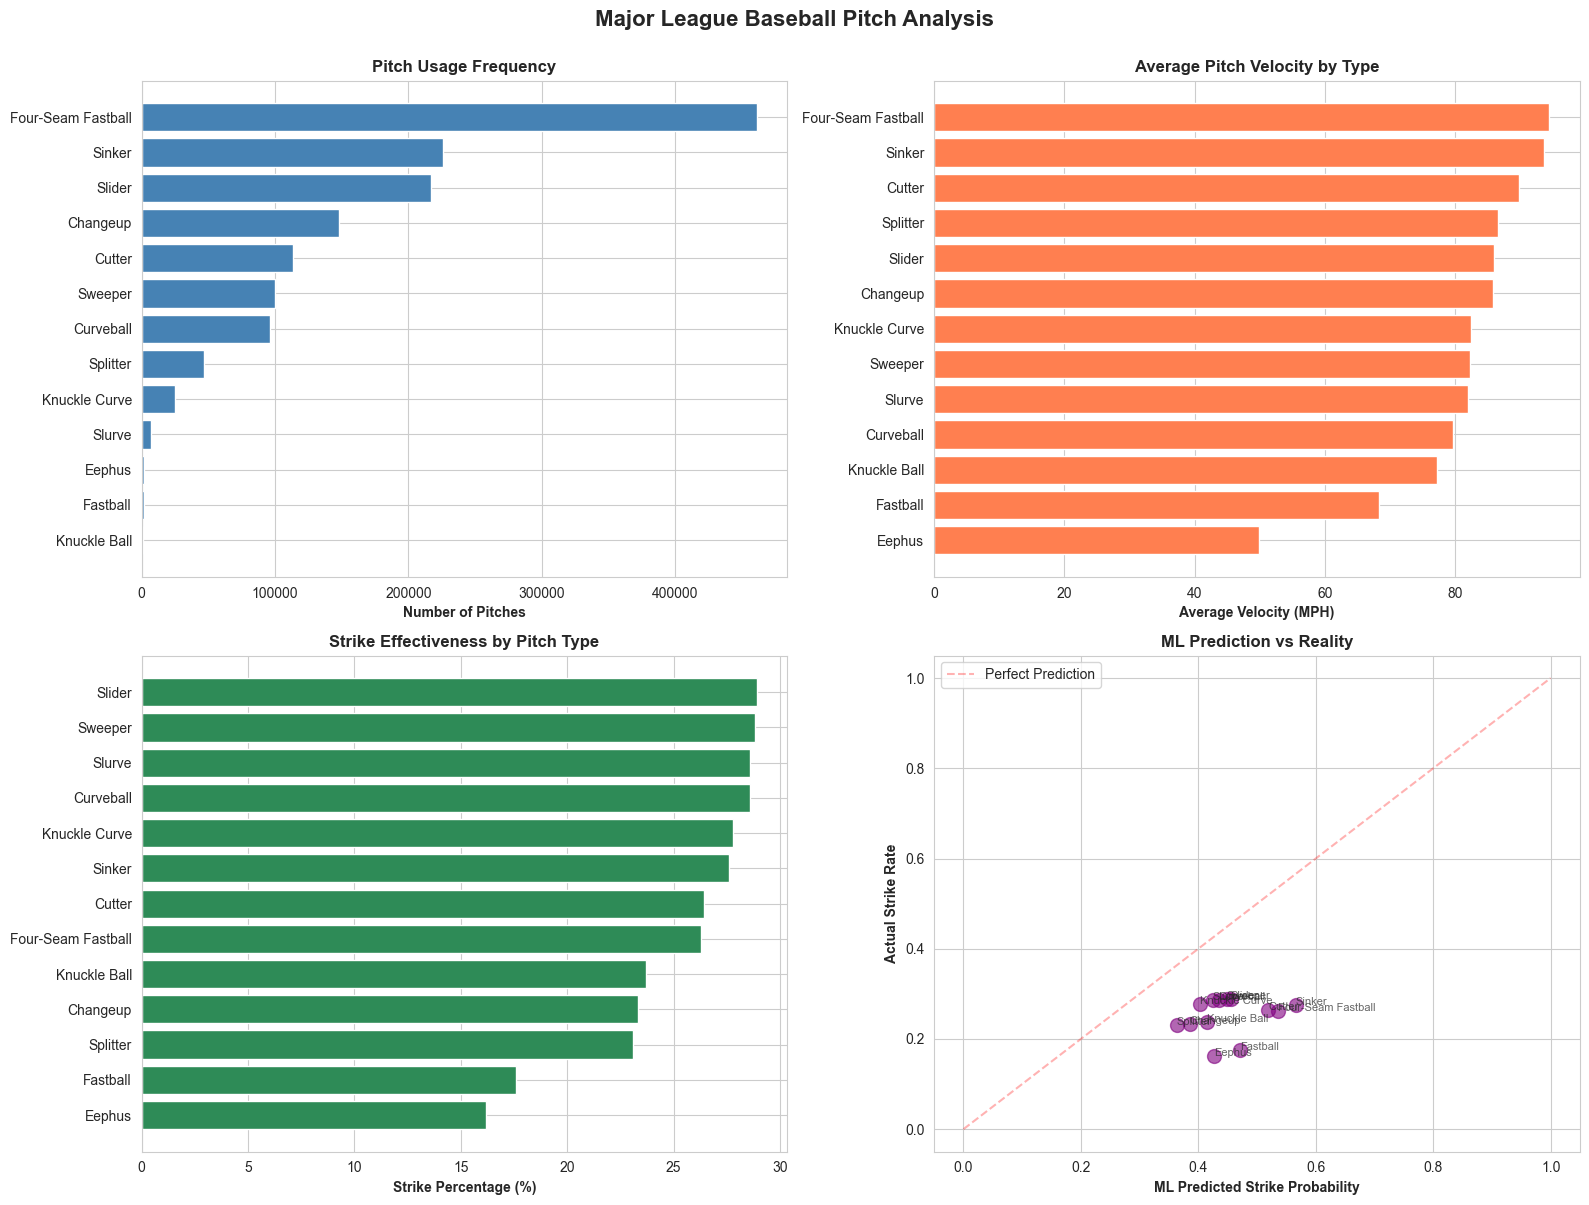


📊 Major League Baseball pitch type analysis complete!


In [10]:
# Create multi-panel visualization for pitch types
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'{LEAGUE_LEVEL} Pitch Analysis', fontsize=16, fontweight='bold', y=1.00)

# 1. Pitch count by type
ax1 = axes[0, 0]
pitch_type_pd_sorted = pitch_type_pd.sort_values('pitch_count', ascending=True)
ax1.barh(pitch_type_pd_sorted['pitch_type_description'], pitch_type_pd_sorted['pitch_count'], color='steelblue')
ax1.set_xlabel('Number of Pitches', fontweight='bold')
ax1.set_title('Pitch Usage Frequency', fontsize=12, fontweight='bold')

# 2. Average velocity by pitch type
ax2 = axes[0, 1]
velocity_sorted = pitch_type_pd.sort_values('avg_velocity', ascending=True)
ax2.barh(velocity_sorted['pitch_type_description'], velocity_sorted['avg_velocity'], color='coral')
ax2.set_xlabel('Average Velocity (MPH)', fontweight='bold')
ax2.set_title('Average Pitch Velocity by Type', fontsize=12, fontweight='bold')

# 3. Strike percentage by pitch type
ax3 = axes[1, 0]
strike_sorted = pitch_type_pd.sort_values('strike_pct', ascending=True)
ax3.barh(strike_sorted['pitch_type_description'], strike_sorted['strike_pct'], color='seagreen')
ax3.set_xlabel('Strike Percentage (%)', fontweight='bold')
ax3.set_title('Strike Effectiveness by Pitch Type', fontsize=12, fontweight='bold')

# 4. ML predicted strike probability vs actual strike rate
ax4 = axes[1, 1]
ax4.scatter(pitch_type_pd['avg_strike_prob'], pitch_type_pd['strike_pct']/100, s=100, alpha=0.6, color='purple')
for idx, row in pitch_type_pd.iterrows():
    ax4.annotate(row['pitch_type_description'], (row['avg_strike_prob'], row['strike_pct']/100), 
                fontsize=8, alpha=0.7)
ax4.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='Perfect Prediction')  # Reference line
ax4.set_xlabel('ML Predicted Strike Probability', fontweight='bold')
ax4.set_ylabel('Actual Strike Rate', fontweight='bold')
ax4.set_title('ML Prediction vs Reality', fontsize=12, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 {LEAGUE_LEVEL} pitch type analysis complete!")


## 5. Power Hitting Analysis - Launch Angle & Exit Velocity

Analyzing the "barrel zone" - optimal launch angle and exit velocity combinations for home runs.


In [11]:
# Get hit data with launch metrics
print("💥 Loading hit data for analysis...")

# Filter for batted balls with launch data
hit_pd = df[(df['hit_launch_speed'].notna()) & 
            (df['hit_launch_angle'].notna()) & 
            (df['hit_launch_speed'] > 50)].copy()

print(f"\n📊 Loaded {len(hit_pd):,} batted balls with launch metrics")
print(f"   Average exit velocity: {hit_pd['hit_launch_speed'].mean():.1f} MPH")
print(f"   Average launch angle: {hit_pd['hit_launch_angle'].mean():.1f}°")


💥 Loading hit data for analysis...

📊 Loaded 247,393 batted balls with launch metrics
   Average exit velocity: 89.7 MPH
   Average launch angle: 13.8°


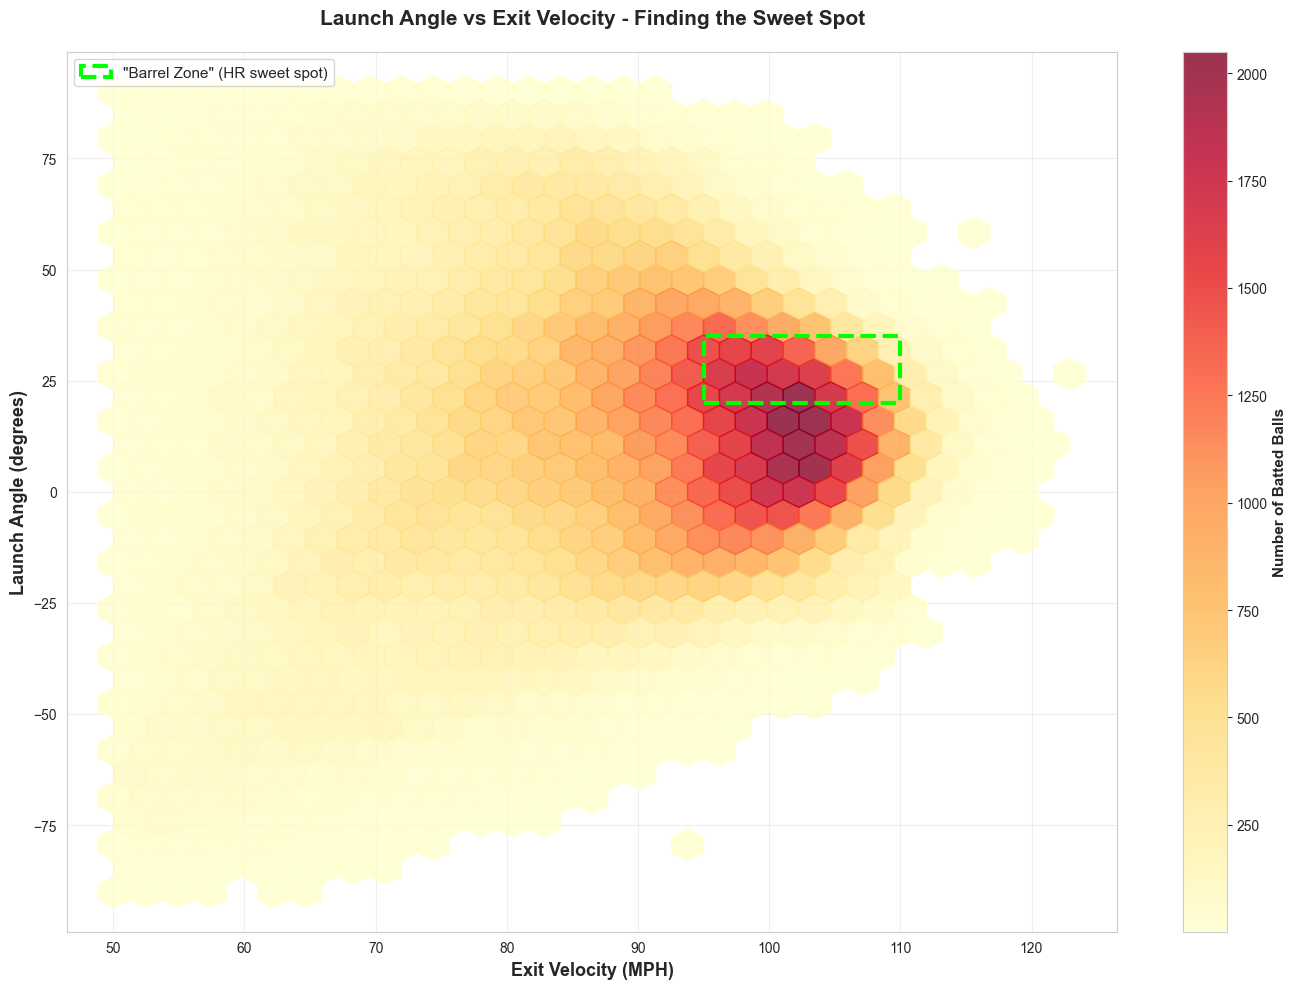


💥 The 'barrel zone' (95-110 MPH, 20-35°) represents optimal home run conditions


In [12]:
# Create launch angle vs exit velocity scatter plot
fig, ax = plt.subplots(figsize=(14, 10))

# Create density plot using hexbin
hb = ax.hexbin(hit_pd['hit_launch_speed'], hit_pd['hit_launch_angle'], 
               gridsize=30, cmap='YlOrRd', mincnt=1, alpha=0.8)

# Add the "barrel zone" overlay (typical home run zone: 95-110 MPH, 20-35 degrees)
from matplotlib.patches import Rectangle
barrel_zone = Rectangle((95, 20), 15, 15, linewidth=3, edgecolor='lime', 
                        facecolor='none', label='"Barrel Zone" (HR sweet spot)', linestyle='--')
ax.add_patch(barrel_zone)

ax.set_xlabel('Exit Velocity (MPH)', fontsize=13, fontweight='bold')
ax.set_ylabel('Launch Angle (degrees)', fontsize=13, fontweight='bold')
ax.set_title('Launch Angle vs Exit Velocity - Finding the Sweet Spot', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

# Add colorbar
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Number of Batted Balls', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💥 The 'barrel zone' (95-110 MPH, 20-35°) represents optimal home run conditions")


## 6. Batter Performance Leaderboard

Creating comprehensive leaderboards for top batters based on various metrics.


In [13]:
# Create batter performance leaderboard
print(f"🏆 Top 20 {LEAGUE_LEVEL} Batters by Barrel Rate (Min 100 PA):")

# Calculate batter metrics
df_batters = df.copy()
df_batters['is_long_ball'] = ((df_batters['hit_trajectory'] == 'fly_ball') & 
                               (df_batters['hit_total_distance'] > 400)).astype(int)
df_batters['is_barrel'] = ((df_batters['hit_launch_speed'] > 95) & 
                            (df_batters['hit_launch_angle'].between(20, 35))).astype(int)

# Group by batter
batter_pd = df_batters.groupby(['batter_full_name', 'batter_side_description']).agg({
    'pitch_index': 'count',
    'hit_launch_speed': 'mean',
    'hit_launch_angle': 'mean',
    'is_long_ball': 'sum',
    'is_barrel': 'sum'
}).rename(columns={
    'pitch_index': 'plate_appearances',
    'hit_launch_speed': 'avg_exit_velo',
    'hit_launch_angle': 'avg_launch_angle',
    'is_long_ball': 'long_balls',
    'is_barrel': 'barrels'
}).reset_index()

# Filter for min 100 PA
batter_pd = batter_pd[batter_pd['plate_appearances'] >= 100]

# Round values
batter_pd['avg_exit_velo'] = batter_pd['avg_exit_velo'].round(1)
batter_pd['avg_launch_angle'] = batter_pd['avg_launch_angle'].round(1)

# Sort and limit to top 20
batter_pd = batter_pd.sort_values('barrels', ascending=False).head(20)

print(batter_pd.to_string(index=False))


🏆 Top 20 Major League Baseball Batters by Barrel Rate (Min 100 PA):
     batter_full_name batter_side_description  plate_appearances  avg_exit_velo  avg_launch_angle  long_balls  barrels
        Shohei Ohtani                    Left               6311           95.2              15.8          77      167
          Aaron Judge                   Right               5894           95.8              19.0          72      150
            Juan Soto                    Left               6197           93.6              10.7          55      140
          Pete Alonso                   Right               5837           91.8              15.0          50      137
       Kyle Schwarber                    Left               6066           93.9              17.7          61      133
         Brent Rooker                   Right               4953           91.2              17.5          48      131
        Marcell Ozuna                   Right               5539           91.1              14.3  

In [14]:
# Create styled pandas dataframe for leaderboard display
print("\n📊 Power Hitters Leaderboard - Styled Table")
print("=" * 100)

# Style the dataframe
styled_df = batter_pd.copy()
styled_df.columns = ['Batter', 'Bats', 'PA', 'Avg EV', 'Avg LA', 'Long Balls', 'Barrels']
styled_df.index = range(1, len(styled_df) + 1)

print(styled_df.to_string())
print("\n" + "=" * 100)
print("Legend: PA=Plate Appearances, EV=Exit Velocity (MPH), LA=Launch Angle (°)")
print("        Long Balls=Fly balls over 400 feet, Barrels=Optimal EV+LA combinations")



📊 Power Hitters Leaderboard - Styled Table
                   Batter   Bats    PA  Avg EV  Avg LA  Long Balls  Barrels
1           Shohei Ohtani   Left  6311    95.2    15.8          77      167
2             Aaron Judge  Right  5894    95.8    19.0          72      150
3               Juan Soto   Left  6197    93.6    10.7          55      140
4             Pete Alonso  Right  5837    91.8    15.0          50      137
5          Kyle Schwarber   Left  6066    93.9    17.7          61      133
6            Brent Rooker  Right  4953    91.2    17.5          48      131
7           Marcell Ozuna  Right  5539    91.1    14.3          47      130
8             Taylor Ward  Right  5387    90.5    17.7          35      129
9          Bobby Witt Jr.  Right  5211    93.0    15.1          33      128
10         Salvador Perez  Right  4640    90.6    18.7          46      126
11        Freddie Freeman   Left  5419    90.3    14.9          33      125
12      Teoscar Hernández  Right  5304    90

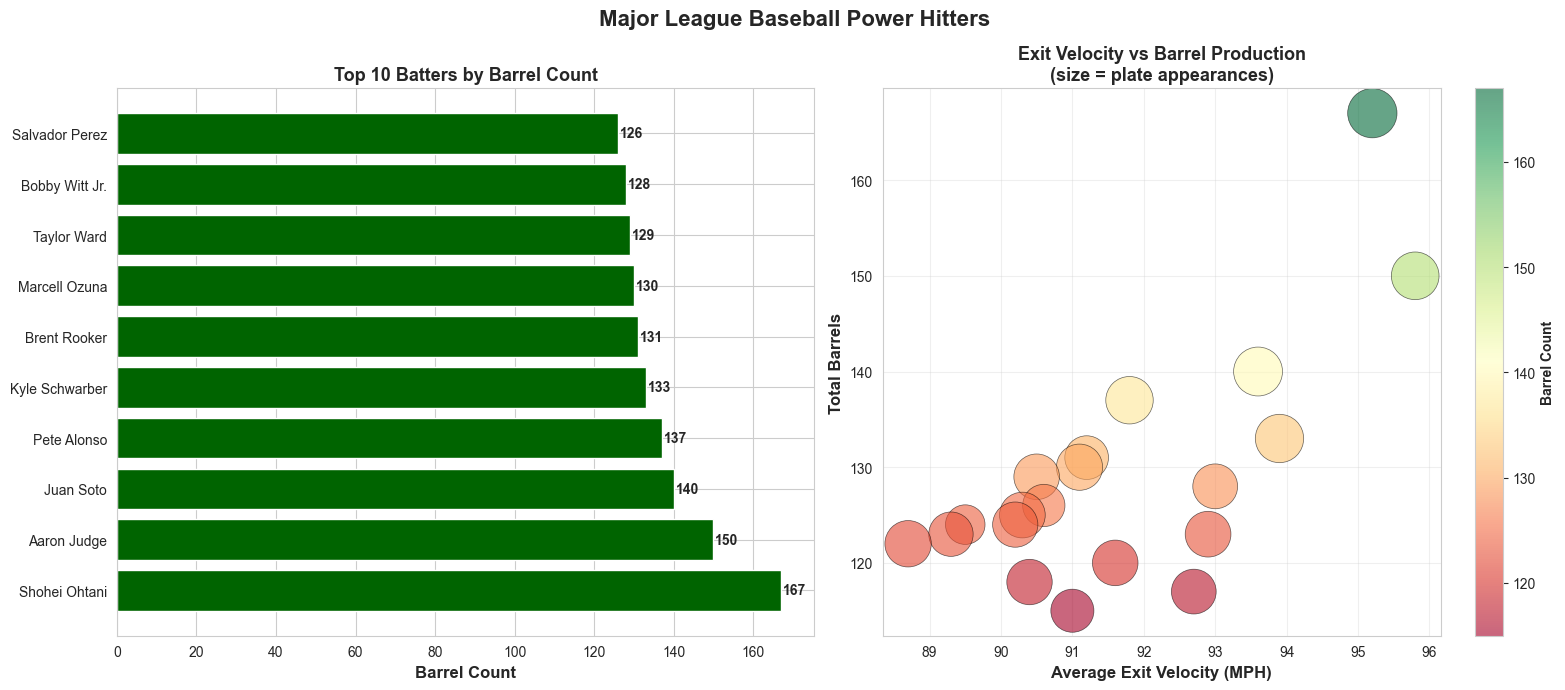


🎯 In Major League Baseball, higher exit velocity generally correlates with more barrels!


In [15]:
# Visualize top power hitters
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'{LEAGUE_LEVEL} Power Hitters', fontsize=16, fontweight='bold')

# Top 10 by barrels
ax1 = axes[0]
top_10_barrels = batter_pd.head(10).sort_values('barrels')
bars1 = ax1.barh(top_10_barrels['batter_full_name'], top_10_barrels['barrels'], color='darkgreen')
ax1.set_xlabel('Barrel Count', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 Batters by Barrel Count', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Add values on bars
for bar in bars1:
    width = bar.get_width()
    ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            va='center', fontsize=10, fontweight='bold')

# Exit velocity vs barrels scatter
ax2 = axes[1]
scatter = ax2.scatter(batter_pd['avg_exit_velo'], batter_pd['barrels'], 
                     s=batter_pd['plate_appearances']/5, alpha=0.6, c=batter_pd['barrels'], 
                     cmap='RdYlGn', edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Average Exit Velocity (MPH)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Barrels', fontsize=12, fontweight='bold')
ax2.set_title('Exit Velocity vs Barrel Production\n(size = plate appearances)', 
             fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Barrel Count', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🎯 In {LEAGUE_LEVEL}, higher exit velocity generally correlates with more barrels!")


## 7. Time Series Analysis - Performance Across Seasons

Analyzing how game dynamics have evolved from 2023 to 2025.


In [16]:
# Analyze trends over time
print("📈 Season-by-Season Trends:")

# Group by season
trend_pd = df.groupby('season').agg({
    'game_pk': 'nunique',
    'pitch_index': 'count',
    'pitch_start_speed': 'mean',
    'pitch_spin_rate': 'mean',
    'hit_launch_speed': 'mean',
    'called_strike_probability': 'mean'
}).rename(columns={
    'game_pk': 'games',
    'pitch_index': 'total_pitches',
    'pitch_start_speed': 'avg_velocity',
    'pitch_spin_rate': 'avg_spin_rate',
    'hit_launch_speed': 'avg_exit_velo',
    'called_strike_probability': 'avg_strike_prob'
}).reset_index()

# Round values
trend_pd['avg_velocity'] = trend_pd['avg_velocity'].round(2)
trend_pd['avg_spin_rate'] = trend_pd['avg_spin_rate'].round(0).astype(int)
trend_pd['avg_exit_velo'] = trend_pd['avg_exit_velo'].round(2)
trend_pd['avg_strike_prob'] = trend_pd['avg_strike_prob'].round(3)

# Sort by season
trend_pd = trend_pd.sort_values('season')

print(trend_pd.to_string(index=False))


📈 Season-by-Season Trends:
 season  games  total_pitches  avg_velocity  avg_spin_rate  avg_exit_velo  avg_strike_prob
   2024   2472         722297         89.17           2257          88.34            0.486
   2025   2477         724180         89.40           2277          88.80            0.494


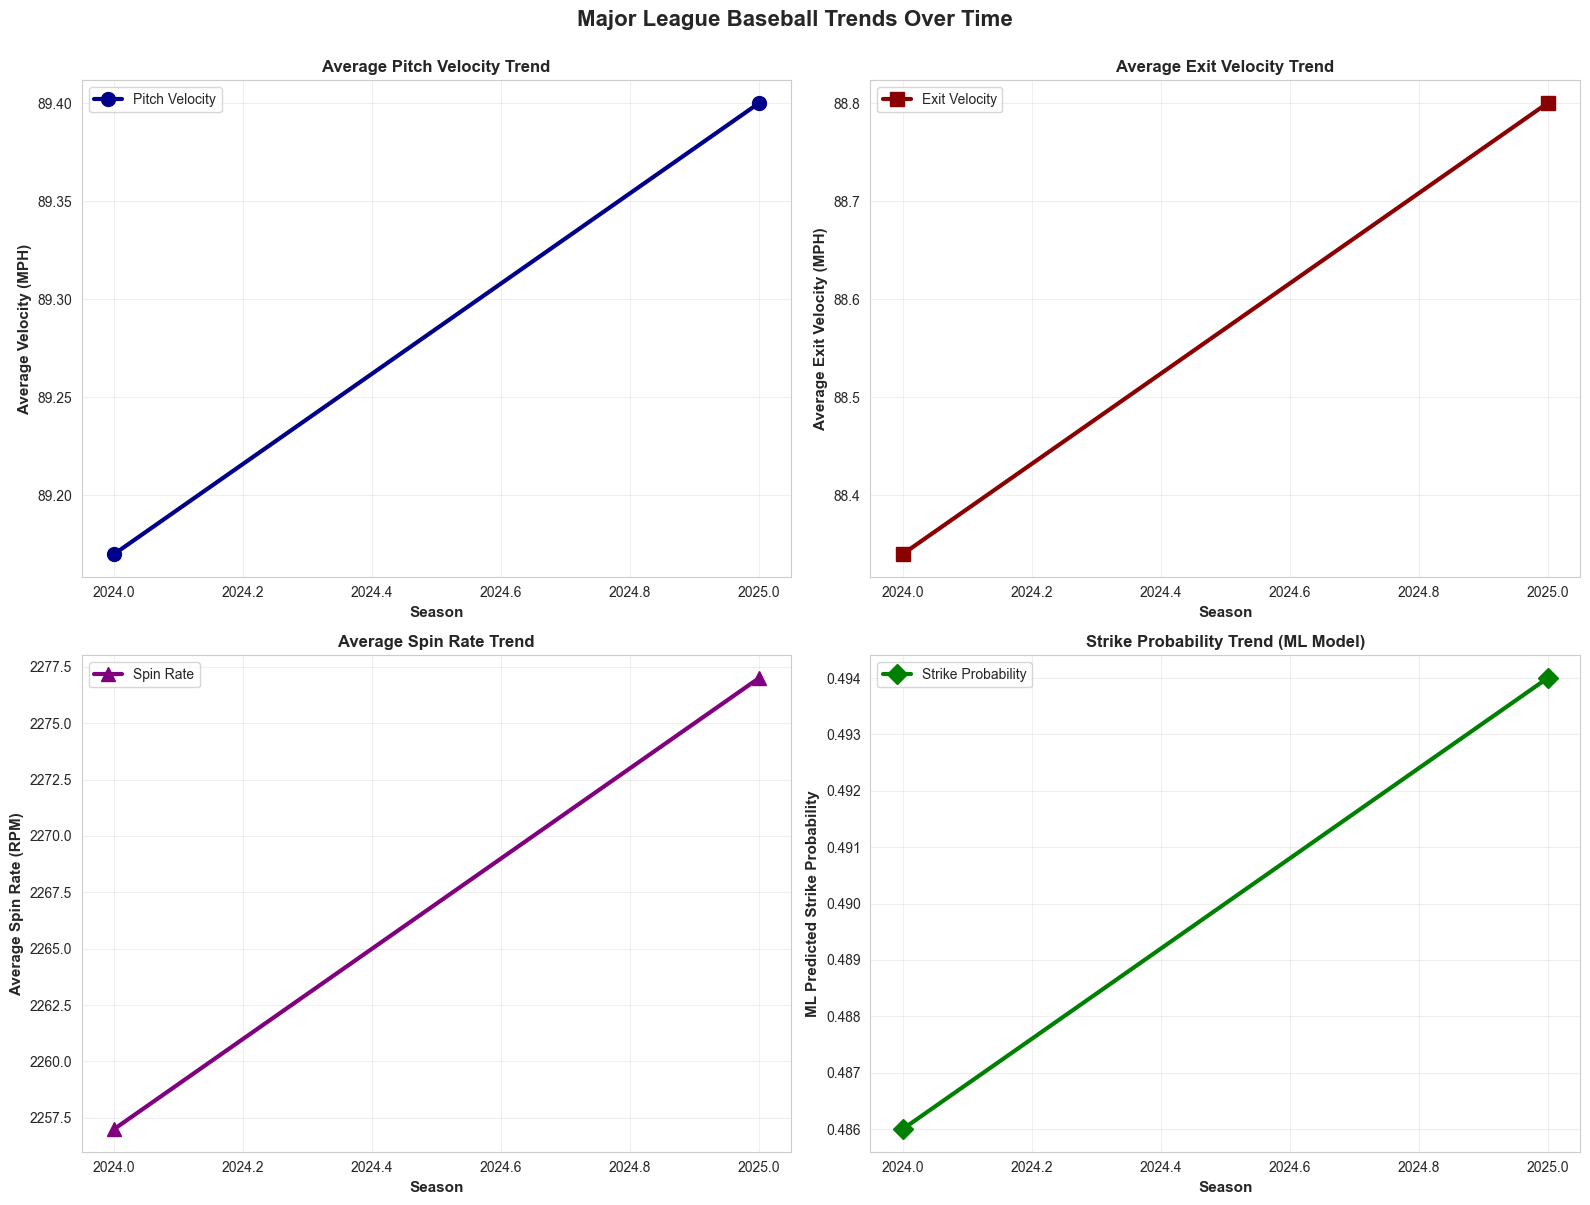


📊 Time series analysis reveals evolving Major League Baseball game dynamics across seasons!


In [17]:
# Visualize trends over time
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'{LEAGUE_LEVEL} Trends Over Time', fontsize=16, fontweight='bold', y=1.00)

# 1. Pitch velocity trends
ax1 = axes[0, 0]
ax1.plot(trend_pd['season'], trend_pd['avg_velocity'], marker='o', linewidth=3, 
         markersize=10, color='darkblue', label='Pitch Velocity')
ax1.set_xlabel('Season', fontweight='bold', fontsize=11)
ax1.set_ylabel('Average Velocity (MPH)', fontweight='bold', fontsize=11)
ax1.set_title('Average Pitch Velocity Trend', fontweight='bold', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Exit velocity trends
ax2 = axes[0, 1]
ax2.plot(trend_pd['season'], trend_pd['avg_exit_velo'], marker='s', linewidth=3, 
         markersize=10, color='darkred', label='Exit Velocity')
ax2.set_xlabel('Season', fontweight='bold', fontsize=11)
ax2.set_ylabel('Average Exit Velocity (MPH)', fontweight='bold', fontsize=11)
ax2.set_title('Average Exit Velocity Trend', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Spin rate trends
ax3 = axes[1, 0]
ax3.plot(trend_pd['season'], trend_pd['avg_spin_rate'], marker='^', linewidth=3, 
         markersize=10, color='purple', label='Spin Rate')
ax3.set_xlabel('Season', fontweight='bold', fontsize=11)
ax3.set_ylabel('Average Spin Rate (RPM)', fontweight='bold', fontsize=11)
ax3.set_title('Average Spin Rate Trend', fontweight='bold', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Strike probability trends
ax4 = axes[1, 1]
ax4.plot(trend_pd['season'], trend_pd['avg_strike_prob'], marker='D', linewidth=3, 
         markersize=10, color='green', label='Strike Probability')
ax4.set_xlabel('Season', fontweight='bold', fontsize=11)
ax4.set_ylabel('ML Predicted Strike Probability', fontweight='bold', fontsize=11)
ax4.set_title('Strike Probability Trend (ML Model)', fontweight='bold', fontsize=12)
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 Time series analysis reveals evolving {LEAGUE_LEVEL} game dynamics across seasons!")


## 8. Session Cleanup


In [18]:
# Cleanup
print("✅ Analysis complete!")
print("   PyIceberg catalog remains open for additional queries")
print("   No session cleanup needed (unlike Spark)")


✅ Analysis complete!
   PyIceberg catalog remains open for additional queries
   No session cleanup needed (unlike Spark)


## ✅ Summary & Key Achievements

This notebook successfully demonstrates **vendor-neutral data access** to Unity Catalog managed Iceberg tables using PyIceberg with SELECT permissions.

### 🎯 What We Accomplished

1. **PyIceberg Setup**: Configured native Python Iceberg client with Unity Catalog REST API
2. **Read-Only Access**: Successfully queried Unity Catalog managed tables from outside Databricks
3. **Authentication**: Securely connected using access tokens and REST API endpoints
4. **Native Pandas Integration**: Direct conversion to Pandas DataFrames for advanced analytics
5. **Data Visualization**: Created compelling charts using matplotlib and seaborn
6. **Real-World Insights**: Analyzed comprehensive MLB pitch-by-pitch data (2023-2025)

### 📊 Analytics We Performed

- **Pitcher Performance**: Identified top pitchers by ML-predicted strike probability
- **Pitch Type Analysis**: Evaluated effectiveness of different pitch types
- **Power Hitting**: Analyzed launch angle and exit velocity "barrel zones"
- **Batter Leaderboards**: Ranked batters by barrel rate and power metrics
- **Time Series**: Tracked game dynamics evolution across multiple seasons

### 🏗️ Architecture Benefits

- **🔓 No Vendor Lock-in**: Use PyIceberg from any Python environment
- **🎯 Centralized Governance**: Unity Catalog maintains metadata, permissions, lineage, and audit trails
- **📈 Lightweight**: No JVM or Spark required - pure Python implementation
- **🌐 Open Standards**: Built on Apache Iceberg for maximum ecosystem compatibility
- **🔐 Secure Access**: Token-based authentication with granular SELECT permissions
- **⚡ Performance**: Direct PyArrow integration for fast data access

### 🚀 Use Cases Enabled

- **Partner Data Sharing**: Secure read-only data collaboration across organizations
- **Local Development**: Data scientists can query production data from their laptops
- **BI Tool Integration**: Connect external analytics tools directly to Unity Catalog
- **Cost-Effective Compute**: Use local or cloud compute for read-heavy workloads
- **Data Science Workflows**: Jupyter notebooks with production data access
- **ETL Pipelines**: Build data pipelines with PyIceberg as the source

### 🔧 Technical Implementation

- **PyIceberg**: Native Python library for Apache Iceberg (no JVM required)
- **REST API**: Unity Catalog Iceberg REST interface for metadata operations
- **S3 Storage**: Direct read access to Iceberg data files with vended credentials
- **PyArrow**: High-performance columnar data format for fast data transfer
- **Pandas Integration**: Seamless conversion for data analysis
- **Visualization**: Professional charts with matplotlib and seaborn

### 💡 Why PyIceberg vs PySpark?

- **Lighter weight**: No JVM, fewer dependencies
- **Faster startup**: Instant connection, no Spark context initialization
- **Better for managed tables**: Works with Unity Catalog managed Iceberg tables
- **Pure Python**: Easier debugging and integration with Python ecosystems
- **Lower memory**: More efficient for read-only analytics

This architecture enables **secure, governed, and cost-effective data collaboration** using modern Python tools while maintaining centralized control through Unity Catalog.
